In [2]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from itertools import chain
from nltk import NaiveBayesClassifier

In [3]:
data = pd.read_csv("book_reviews_sample.csv")
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [11]:
#cleaning reviewText column text by removing punctuation
data['reviewText_clean'] = data['reviewText'].str.lower()
data['reviewText_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", '', x['reviewText_clean']), axis=1)
data.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [17]:
#Vader - A rule-based sentiment analysis method
#Using Vader on the cleaned text for sentiment analysis
vader_sentiment_analyzer = SentimentIntensityAnalyzer()
#as Vader comes with a built-in list of lexicons, we are not passing anything in parentheses while initialising
data['vader_score'] = data['reviewText_clean'].apply(lambda review: vader_sentiment_analyzer.polarity_scores(review)['compound'])
data.head()

,index,reviewText,rating,reviewText_clean,vader_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [18]:
#assigning tags to vader scores
bins = [-1,-0.1,0.1,1]
sentiment_tags = ['negative', 'neutral', 'positive']
data['vader_sentiment_tag'] = pd.cut(data['vader_score'], bins, labels=sentiment_tags)
data.head()

,index,reviewText,rating,reviewText_clean,vader_score,vader_sentiment_tag
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative


<Axes: xlabel='vader_sentiment_tag'>

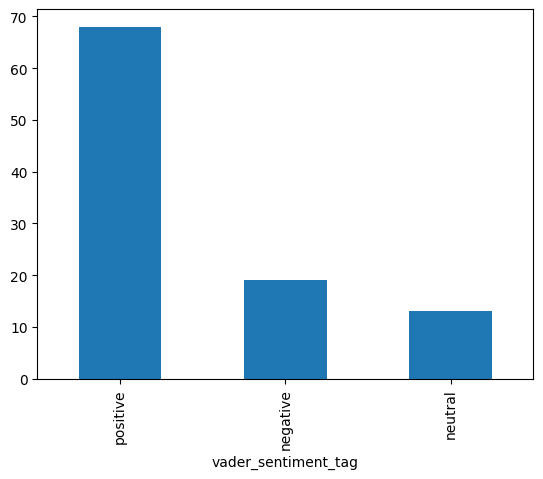

In [20]:
#showing the results with plotting on a chart
data['vader_sentiment_tag'].value_counts().plot.bar()

In [21]:
#Using pre-trained models for sentiment analysis
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


<Axes: xlabel='transformer_sentiment_tag'>

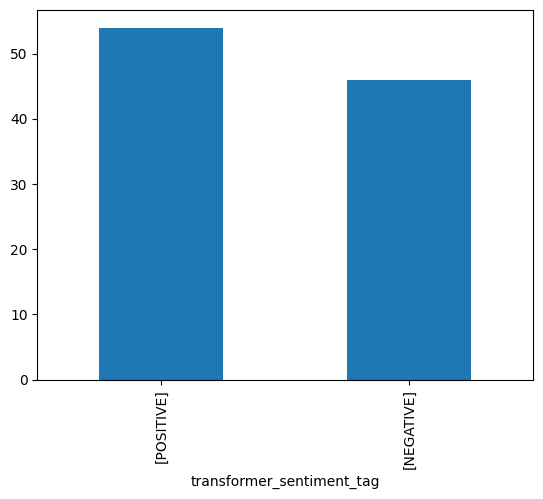

In [24]:
transformer_labels = []
for review in data['reviewText_clean'].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_lables = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_lables)

data['transformer_sentiment_tag'] = transformer_labels
data['transformer_sentiment_tag'].value_counts().plot.bar()